In [ ]:
#import packages
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import pycountry 
import time

Q1

In [2]:

BASE = "https://api.openalex.org/works"

def count_ai_in_title():
    params = {
        "filter": 'title.search:"artificial intelligence"',
        "per-page": 1,       
    }
    response = requests.get(BASE, params=params)
    data = response.json()
    return data["meta"]["count"]

print("Total works with 'artificial intelligence' in title:", count_ai_in_title())


Total works with 'artificial intelligence' in title: 196794


Q2

In [ ]:
import pycountry 
# 1 url
params = {
    "filter": 'title.search:"artificial intelligence",from_publication_date:2020-01-01',
    "group_by": "authorships.institutions.country_code", 
    "sort": "count:desc",
}

# 2 get json
resp = requests.get(BASE, params=params, timeout=60)
resp.raise_for_status()
data = resp.json()

# 3) group by, create DataFrame
rows = []
for country in data["group_by"]:
    url = country["key"]                      # OpenAlex  URL
    code = url.split("/")[-1]           # get URL's last part (US, CN, GB...)
    try:
        name = pycountry.countries.get(alpha_2=code).name
    except:
        name = code                     
    rows.append({                          # add url, country code, country name and count to df
        "url": url,
        "country_code": code,
        "country_name": name,
        "n_ai_pubs": country["count"]
    })

df = pd.DataFrame(rows).sort_values("n_ai_pubs", ascending=False, ignore_index=True)


print(df.head(20))  

                                  url country_code               country_name  \
0   https://openalex.org/countries/US           US              United States   
1   https://openalex.org/countries/CN           CN                      China   
2   https://openalex.org/countries/IN           IN                      India   
3   https://openalex.org/countries/GB           GB             United Kingdom   
4   https://openalex.org/countries/IT           IT                      Italy   
5   https://openalex.org/countries/DE           DE                    Germany   
6   https://openalex.org/countries/CA           CA                     Canada   
7   https://openalex.org/countries/AU           AU                  Australia   
8   https://openalex.org/countries/TR           TR                    Türkiye   
9   https://openalex.org/countries/ES           ES                      Spain   
10  https://openalex.org/countries/RU           RU         Russian Federation   
11  https://openalex.org/cou

Chatgpt says it is not searching by page, because using group_by we get all the data.So I just group by country.

Q3

In [ ]:
BASE = "https://api.openalex.org/works"

#1 parameter 
# filter title with "artificial intelligence" and time from 2020-01-01
params = {
    "filter": 'title.search:"artificial intelligence",from_publication_date:2020-01-01',
    "sort": "cited_by_count:desc",
    "per-page": 10,
    "select": "id,display_name,publication_year,cited_by_count,authorships",
}
#2 get json
resp = requests.get(BASE, params=params, timeout=60)
resp.raise_for_status()               
data = resp.json()  

#3 create dataframe

rows = []
for result in data.get("results", []): 
    work_url = result.get("id")
    title = result.get("display_name", "")
    year = result.get("publication_year")
    cited_by = result.get("cited_by_count", 0)

    # get author and institution info
    authors = []
    institutions = set()  
    for author in result.get("authorships", []):
        # author name
        if author.get("author"):
            name = author["author"].get("display_name")
            if name:
                authors.append(name)
        # institution
        for inst in author.get("institutions", []):
            inst_name = inst.get("display_name")
            if inst_name:
                institutions.add(inst_name)
#add info to dataframe
    rows.append({ 
        "title": title,
        "year": year,
        "cited_by": cited_by,
        "authors": "; ".join(authors),                     
        "institutions": "; ".join(sorted(institutions)),   
        "openalex_url": work_url,                          
    })

# 
df_top10 = pd.DataFrame(rows)

df_top10 = df_top10.sort_values("cited_by", ascending=False, ignore_index=True)

print(df_top10)

                                               title  year  cited_by  \
0     Artificial Intelligence in Education: A Review  2020      2267   
1  The role of artificial intelligence in achievi...  2020      2195   
2  Using Artificial Intelligence to Detect COVID-...  2020      1956   
3  Revolutionizing healthcare: the role of artifi...  2023      1629   
4  Comparing Physician and Artificial Intelligenc...  2023      1576   
5  A Survey on Explainable Artificial Intelligenc...  2020      1560   
6  Human Trust in Artificial Intelligence: Review...  2020      1419   
7  Artificial Intelligence (AI) applications for ...  2020      1416   
8  Photonics for artificial intelligence and neur...  2021      1399   
9  Review of Artificial Intelligence Techniques i...  2020      1396   

                                             authors  \
0             Lijia Chen; Pingping Chen; Zhijian Lin   
1  Ricardo Vinuesa; Hossein Azizpour; Iolanda Lei...   
2  Lin Li; Lixin Qin; Zeguo Xu; Youbing

Q4

In [ ]:
import requests, time
import pandas as pd
BASE = "https://api.openalex.org/works"                  
START_DATE = "2000-01-01"  
MAILTO = "zachzhouyc@gmail.com"                      
KEYWORDS = [                     # create keywords list
    "artificial intelligence",                 
    "LLM",                                     
    "GPT",                                     
    "large language model"                     
]

# create a dataset to store info
df_all = pd.DataFrame(columns=["year", "count", "keyword"])

# get info by each keyword and store in df_all
#
for kw in KEYWORDS:
    # parameters
    params = {
        "filter": f'title.search:"{kw}",from_publication_date:{START_DATE}',
        "group_by": "publication_year",
        "sort": "key:asc",
        "mailto": MAILTO
    }
    time.sleep(0.5) 

    # get json
    resp = requests.get(BASE, params=params, timeout=60)
    resp.raise_for_status()           
    data = resp.json()

    # group_by 
    # each looks like {"key": "2005", "key_display_name": "2005", "count": 123}
    group = data.get("group_by", [])

    # filter year that is not None

    df_kw = pd.DataFrame({
        "year": [int(g["key"]) for g in group if g.get("key") is not None],
        "count": [int(g["count"]) for g in group],
    })
    df_kw["keyword"] = kw

    df_all = pd.concat([df_all, df_kw], ignore_index=True)

    

C:\Users\Zach\AppData\Local\Temp\ipykernel_23076\2109909024.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sub_full["count"] = sub_full["count"].fillna(0).astype(int)
C:\Users\Zach\AppData\Local\Temp\ipykernel_23076\2109909024.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sub_full["count"] = sub_full["count"].fillna(0).astype(int)
C:\Users\Zach\AppData\Local\Temp\ipykernel_23076\2109909024.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_obje

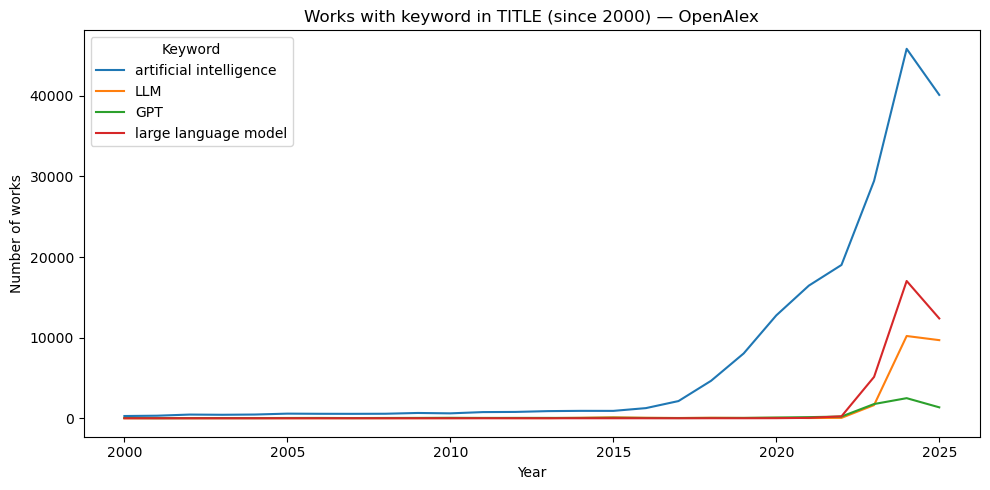

    year  count                  keyword
0   2000    277  artificial intelligence
1   2001    315  artificial intelligence
2   2002    456  artificial intelligence
3   2003    431  artificial intelligence
4   2004    461  artificial intelligence
5   2005    572  artificial intelligence
6   2006    553  artificial intelligence
7   2007    548  artificial intelligence
8   2008    559  artificial intelligence
9   2009    655  artificial intelligence
10  2010    608  artificial intelligence
11  2011    763  artificial intelligence


In [19]:


year_min, year_max = 2000, datetime.now().year
full_years = pd.DataFrame({"year": list(range(year_min, year_max + 1))})

# === 4.1 Create a new completed table df_completed: 
# for each keyword, merge with the full list of years ===
df_completed_list = []  # a list to store intermediate results
for kw in KEYWORDS:
    sub = df_all[df_all["keyword"] == kw].copy()
    # Use full_years as the baseline, left-join with this keyword's yearly counts
    sub_full = full_years.merge(sub, on="year", how="left")
    # Fill missing counts with 0, and add the keyword column
    sub_full["count"] = sub_full["count"].fillna(0).astype(int)
    sub_full["keyword"] = kw
    df_completed_list.append(sub_full)

# Concatenate all keywords back together
df_completed = pd.concat(df_completed_list, ignore_index=True)

# plot
plt.figure(figsize=(10, 5))
for kw in KEYWORDS:
    sub = df_completed[df_completed["keyword"] == kw]
    plt.plot(sub["year"], sub["count"], label=kw)
plt.title("Works with keyword in TITLE (since 2000) — OpenAlex")
plt.xlabel("Year")
plt.ylabel("Number of works")
plt.legend(title="Keyword")
plt.tight_layout()
plt.show()


print(df_completed.head(12))

In the plot, we can find that there are much more papers with "artificial intelligence" in title than papers with other keywords. We can also find that the number of papers with "artificial intelligence" in title remains small untill 2017, after that the number increases rapidly.(2025 has less papers than 2024 because 2025 is not over yet). For keywords"LLM","GPT","large language model", their numbers began to grow rapidly starting in 2022.
